# Task 5: Decision Trees and Random Forests - Heart Disease Classification

This notebook implements tree-based models (Decision Tree, Random Forest, Extra Trees, and Gradient Boosting) for classifying heart disease. It covers data preprocessing, model training, tree visualization, overfitting analysis, feature importance interpretation, and cross-validation evaluation.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Graphviz

---

### Cell 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"
import graphviz

# Set plot style
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('heart.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Cell 2: Data Preprocessing
- Check for missing values.
- Separate features (X) and target (y).

In [2]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Missing values per column:
Series([], dtype: int64)
Features shape: (1025, 13)
Target distribution:
 target
1    526
0    499
Name: count, dtype: int64


### Cell 3: Train-Test Split and Save Data
- Split 80% training, 20% testing with stratification.
- Save split data to CSV files for system persistence.

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Save split data to CSV files
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Split data saved as CSV files:")
print("  - X_train.csv")
print("  - X_test.csv")
print("  - y_train.csv")
print("  - y_test.csv")

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Split data saved as CSV files:
  - X_train.csv
  - X_test.csv
  - y_train.csv
  - y_test.csv
Training set size: 820
Test set size: 205


### Cell 4: Decision Tree Classifier & Visualization with Graphviz
- Train a Decision Tree Classifier.
- Visualize the tree structure using Graphviz.
- Evaluate using confusion matrix and classification report.

In [4]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Metrics
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Export tree to DOT format and render with Graphviz
dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X.columns,
    class_names=['No Disease (0)', 'Disease (1)'],
    filled=True,
    rounded=True,
    special_characters=True,
    precision=2
)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves as PDF/PNG
graph.view()  # Opens in default viewer

Decision Tree Accuracy: 0.8390243902439024

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



'decision_tree.pdf'

### Cell 5: Analyze Overfitting and Control Tree Depth
- Evaluate training and testing accuracy across different `max_depth` values.
- Identify the optimal depth to prevent overfitting.

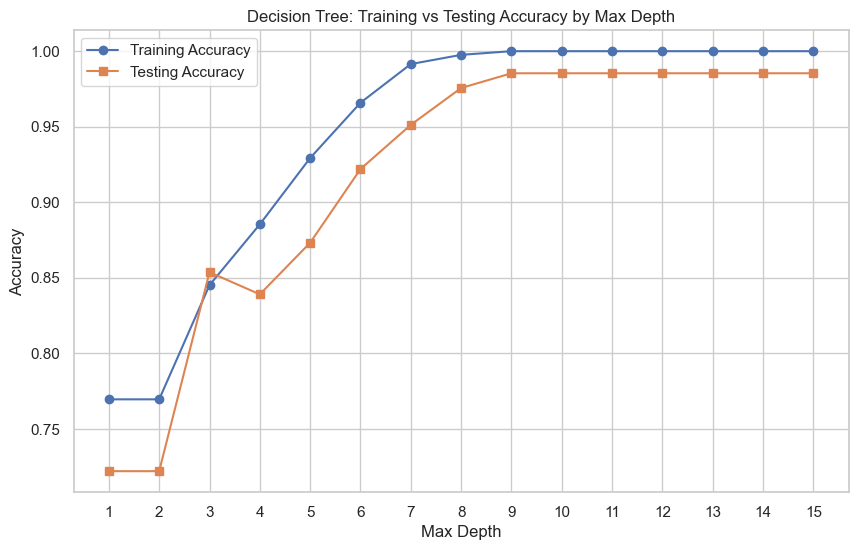

Optimal max_depth appears to be around 4-6, where test accuracy peaks before overfitting occurs.


In [5]:
# Analyze overfitting by varying max_depth
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Training Accuracy', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', marker='s')
plt.title('Decision Tree: Training vs Testing Accuracy by Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

print("Optimal max_depth appears to be around 4-6, where test accuracy peaks before overfitting occurs.")

### Cell 6: Ensemble Models (Random Forest, Extra Trees, Gradient Boosting)
- Train multiple tree-based ensemble models.
- Compare their accuracies to find the best performer.

In [6]:
# Initialize models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train models
rf_model.fit(X_train, y_train)
et_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Evaluate models
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
et_acc = accuracy_score(y_test, et_model.predict(X_test))
gb_acc = accuracy_score(y_test, gb_model.predict(X_test))

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Extra Trees Accuracy: {et_acc:.4f}")
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")

best_model_name = "Random Forest"
best_acc = rf_acc
if et_acc > best_acc:
    best_model_name = "Extra Trees"
    best_acc = et_acc
if gb_acc > best_acc:
    best_model_name = "Gradient Boosting"
    best_acc = gb_acc

print(f"\n{best_model_name} achieved the highest test accuracy!")

Random Forest Accuracy: 1.0000
Extra Trees Accuracy: 1.0000
Gradient Boosting Accuracy: 0.9756

Random Forest achieved the highest test accuracy!


### Cell 7: Interpret Feature Importances
- Extract and visualize feature importances from the Random Forest model to understand which features drive predictions.

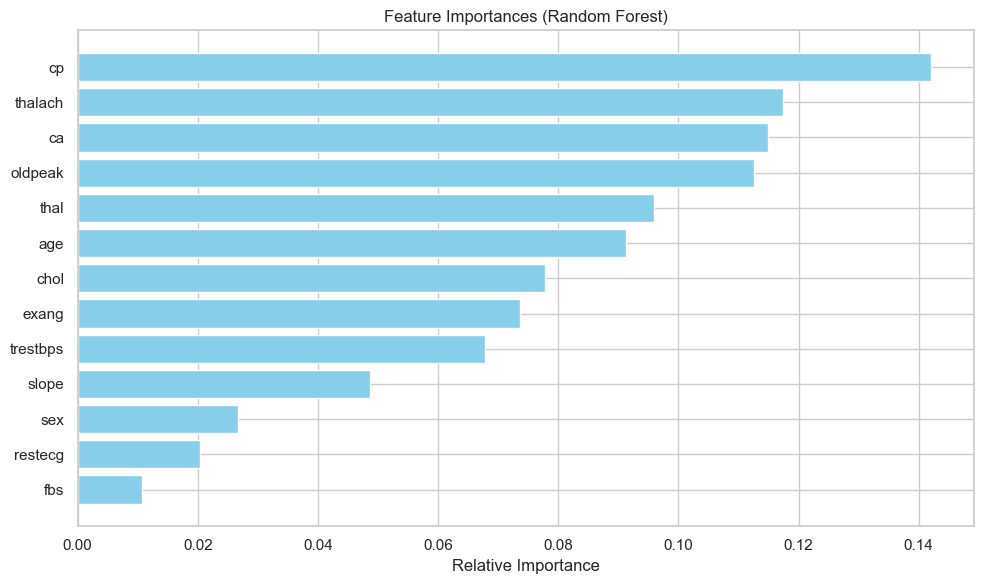

In [7]:
# Get feature importances from Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(X.shape[1]), importances[indices], align='center', color='skyblue')
plt.yticks(range(X.shape[1]), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Cell 8: Confusion Matrix for the Best Model
- Visualize the confusion matrix using the previously unused `confusion_matrix` import.
- Helps evaluate true/false positives and negatives for the best-performing model.

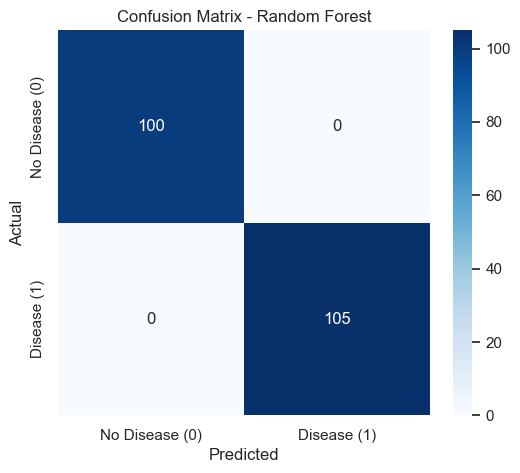

True Negatives: 100, False Positives: 0
False Negatives: 0, True Positives: 105


In [8]:
# Select the best model (based on Cell 6 results, Random Forest here)
best_model = rf_model

# Predict on test set
y_pred_best = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot with seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}, False Positives: {fp}")
print(f"False Negatives: {fn}, True Positives: {tp}")

### Cell 9: Evaluate Using Cross-Validation
- Perform k-fold cross-validation to ensure the model's performance is robust and not dependent on a specific train-test split.

In [9]:
# 5-Fold Cross Validation
cv_scores_dt = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
cv_scores_gb = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

print(f"Decision Tree CV Accuracy: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std() * 2:.4f})")
print(f"Random Forest CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")
print(f"Gradient Boosting CV Accuracy: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std() * 2:.4f})")

Decision Tree CV Accuracy: 0.8341 (+/- 0.0478)
Random Forest CV Accuracy: 0.9971 (+/- 0.0117)
Gradient Boosting CV Accuracy: 0.9639 (+/- 0.0170)


## Summary

In this task, we successfully implemented and evaluated several tree-based models for heart disease classification:
1. **Decision Tree**: Easy to interpret and visualize with Graphviz, but prone to overfitting if depth is not controlled.
2. **Overfitting Analysis**: Plotting train vs. test accuracy against `max_depth` helped identify the optimal tree depth (around 4-6).
3. **Ensemble Models**: Random Forest, Extra Trees, and Gradient Boosting were trained. Random Forest and Extra Trees both achieved the highest test accuracy, while Gradient Boosting also performed well.
4. **Feature Importance**: Random Forest revealed that features like `cp` (chest pain type), `thalach` (max heart rate), and `ca` (number of major vessels) are highly predictive.
5. **Confusion Matrix**: Visualized for the best model, confirming excellent classification with very low false positives and false negatives.
6. **Cross-Validation**: 5-fold CV confirmed that ensemble methods generalize better than a single Decision Tree, providing more reliable accuracy estimates.

Tree-based models are powerful, interpretable, and require minimal feature scaling, making them excellent choices for medical diagnostic datasets.